# Simulacion de Monte Carlo

## Librerias 

In [6]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

## 🎯 Caso de los Dardos 

### Funcion python 



Ahora vamos a ver cómo el azar puede calcular una constante matemática precisa. Este es el ejemplo "Hola Mundo" de Monte Carlo.

Imagina que tienes un tablero cuadrado de madera en la pared.

1. El cuadrado mide **2 metros de lado**.
2. Dibujas un **círculo** inscrito perfectamente dentro (tocando los bordes). El radio del círculo es **1 metro**.

**El Experimento:**
Te vendas los ojos y empiezas a lanzar miles de dardos al cuadrado. Asumimos que eres muy malo tirando, por lo que los dardos caen en cualquier punto del cuadrado con la misma probabilidad (distribución uniforme). No apuntas al centro, simplemente tiras al azar dentro del marco.

**La Lógica:**
Después de tirar, digamos, 1,000 dardos, cuentas dónde cayeron:

* **Total de dardos:** 1,000 (todos caen dentro del cuadrado).
* **Dardos dentro del círculo:** Digamos que cuentas 785.

**¿Cómo obtenemos Pi () de esto?**
Aquí entra la geometría básica. La probabilidad de que un dardo caiga en el círculo depende de qué tan grande es el círculo comparado con el cuadrado.

$\frac{\text{Área del Círculo}}{\text{Área del Cuadrado}} = \frac{\text{Dardos en el Círculo}}{\text{Total de Dardos}}$

Sabemos las áreas por fórmula:

* Área Círculo = $\pi \cdot r^2 = \pi \cdot 1^2 = \pi$
* Área Cuadrado = $\text{lado} \cdot \text{lado} = 2 \cdot 2 = 4$

Entonces la relación es:

$$\frac{\pi}{4} \approx \frac{\text{Dardos en el Círculo}}{\text{Total de Dardos}}$$

Si despejamos $\pi$:

$$\pi \approx 4 \times (\frac{\text{Dardos en el Círculo}}{\text{Total de Dardos}})$$

En nuestro ejemplo de los 1,000 dardos:

$$\pi \approx 4 \times (\frac{785}{1000}) = 4 \times 0.785 = 3.14$$

¡Usamos el azar para encontrar un número constante!

In [7]:
def dardos(N):
    # 2. GENERAR EL AZAR (LANZAR DARDOS)
    # Generamos N coordenadas X e Y aleatorias entre -1 y 1
    # Esto simula el cuadrado de lado 2
    x = np.random.uniform(low=-1, high=1, size=N)
    y = np.random.uniform(low=-1, high=1, size=N)

    # 3. APLICAR LÓGICA DEL SISTEMA (GEOMETRÍA)
    # Calculamos la distancia al centro (0,0) usando Pitágoras: x^2 + y^2
    # No necesitamos la raíz cuadrada porque si r^2 <= 1, entonces r <= 1
    distancias_al_cuadrado = x**2 + y**2

    # 4. EVALUAR RESULTADOS
    # Creamos un filtro: ¿Cayó el dardo dentro del círculo? (Distancia <= 1)
    # Esto crea un array de True (1) y False (0)
    esta_adentro = distancias_al_cuadrado <= 1

    # 5. AGREGAR (CONTAR)
    # Sumamos los "True" para saber cuántos cayeron dentro
    dardos_en_circulo = np.sum(esta_adentro)

    # 6. CALCULAR PI
    # Fórmula: Pi ~= 4 * (Dardos Adentro / Total Dardos)
    pi_estimado = 4 * (dardos_en_circulo / N)

    print(f"Usando {N} dardos, estimamos Pi como: {pi_estimado}")
    print(f"Valor real de Pi (aprox): {np.pi}")
    print(f"Error: {abs(pi_estimado - np.pi)}")

### Evaluacion de parametros

In [8]:
# 1. DEFINIR PARÁMETROS
# Cantidad de 10000 dardos a lanzar (Simulaciones)
N1 = 10000 
# Cantidad de 10 dardos a lanzar (Simulaciones)
N2 = 10

In [9]:
dardos(N1)

Usando 10000 dardos, estimamos Pi como: 3.1392
Valor real de Pi (aprox): 3.141592653589793
Error: 0.0023926535897929035


In [10]:
dardos(N2)

Usando 10 dardos, estimamos Pi como: 2.8
Valor real de Pi (aprox): 3.141592653589793
Error: 0.3415926535897933


### Conclusion

Los resultados validan empíricamente la Ley de los Grandes Números. Se observa que la precisión de la estimación de $\pi$ es directamente proporcional al tamaño de la muestra ($N$). Al incrementar las iteraciones, la varianza del estimador disminuye, reduciendo el error de muestreo y logrando que el valor calculado converja asintóticamente hacia el valor teórico real.

- **Convergencia**: Existe una relación inversa entre el número de simulaciones ($N$) y el error de estimación.
- **Precisión**: Al aumentar $N$, la varianza de los resultados disminuye, generando una estimación más robusta.
- **Validación**: El método de Monte Carlo requiere un $N$ suficientemente grande para minimizar el ruido aleatorio inherente al muestreo estocástico.

## 💸 El precio de una accion 

A diferencia de los dardos (donde se usa una *distribución Uniforme* porque cualquier punto del cuadrado valía lo mismo), en finanzas se utiliza una *distribución Normal* (la campana de Gauss), porque los rendimientos diarios suelen acumularse cerca del promedio.

La Traducción al Código:

1. **El escenario:** Un año de trading (252 días).
2. **El activo:** Una acción que empieza en $100 USD.
3. **Drift (Tendencia):** Esperamos que crezca un 10% al año (0.10).
4. **Volatilidad (Riesgo):** Tiene una desviación estándar del 20% (0.20).

Se calcula el precio día a día usando la lógica multiplicativa (interés compuesto):
$$Precio_{hoy} = Precio_{ayer} \times (1 + \text{RetornoAleatorio})$$

### 1. El Estándar de la Industria: "Todo es Anual"


En finanzas, cuando alguien dice *"Esta acción rinde un 10%"* o *"Tiene una volatilidad del 20%"*, **siempre se refieren a un Año**.

*  $\mu$ (Mu) = 0.10 (10% anual)
*  $\sigma$ (Sigma) = 0.20 (20% anual)

Pero la siguiente simulación es **diaria** (el bucle `for` avanza día por día). Nose puede aplicar un 10% de ganancia cada día (¡serian todos millonarios y enl mercado seria insostenible!). Se tiene que **escalar** esos valores anuales a "pedacitos" diarios.

### 2. Fórmulas de Conversión


Anclaje entre la física y las finanzas: Se asume que un año bursátil tiene **252 días** (quitando fines de semana y feriados).

#### A. La fórmula del Drift (Tendencia) - Escala Lineal

El retorno es una tasa de cambio como la velocidad. Si se viaja a 100 km/h, en media hora se vaiaja a 50 km. Es lineal.

$$\mu_{diario} = \frac{\mu_{anual}}{252}$$

*En el código:* `mu_diario = mu / T`

Si el el **Drift ()** es la velocidad crucero que se pone en un coche de una autopista perfectamente recta y sin tráfico.

* Si la velocidad objetivo es **100 km/h** (valor promedio precio anual).
* Y se quiere saber cuánto se espera avanzar en **media hora** (Escala de tiempo fraccionada).

La lógica es lineal:

$$\text{Distancia Esperada} = \text{Velocidad Total} \times \text{Fracción del Tiempo}$$

$$\text{Distancia} = 100 \text{ km/h} \times 0.5 \text{ h} = 50 \text{ km}$$

**En Finanzas:**
Si se espera un retorno del **10% en un año** (252 días), ¿cuánto "pedacito" de ese retorno se espera acumular en **1 solo día**?

Se divide el total en partes iguales. Es una regla de tres simple:

$$\mu_{diario} = \frac{\mu_{anual}}{\text{Total Días (T)}}$$

Esta fórmula es una **Relación Lineal** porque si se grafica cómo se acumula ese retorno esperado día tras día, se obtiene una línea recta perfecta. No hay exponentes, ni raíces cuadradas.

#### Formula de conversion lineal

Si la ecuacion de la recta tiene el siguiente comportamiento: 

Si: $$\mu_{diario} = \frac{\mu_{anual}}{\text{Total Días (T)}}$$

$$\mu_{diario} \cdot \text{Total Días (T)} = \mu_{anual}$$

$$
\mu_{diario} \cdot \text{Total Días (T)} - \mu_{anual}=0
$$ 

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_16686/3382687877.py:23: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Visualización de la Linealidad del Drift ($\mu$)", fontsize=14, fontweight='bold')


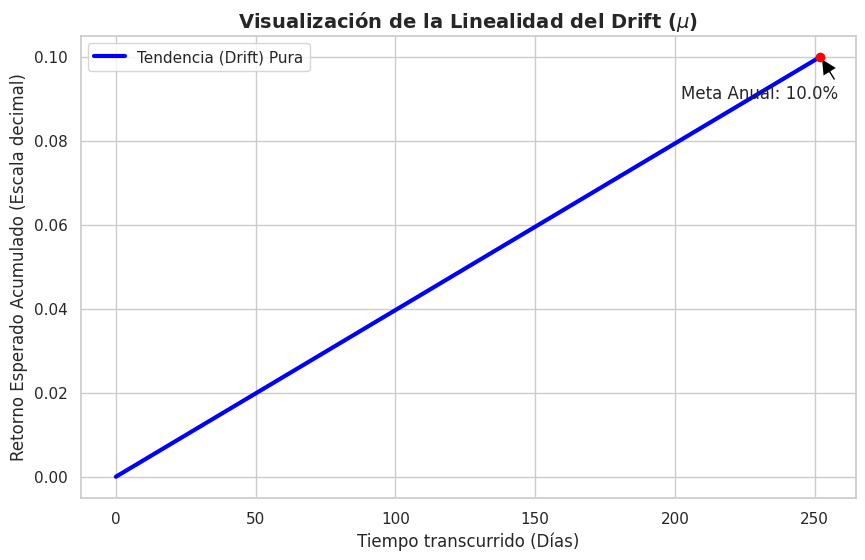

Drift acumulado en el día 126 (mitad de año): 0.0500 (Debería ser aprox 0.05)


In [11]:
# Configurar el estilo visual (opcional, para que se vea más moderno)
sns.set_theme(style="whitegrid")

# --- 1. PARÁMETROS ---
T = 252           # Días totales (eje X)
mu_anual = 0.10   # se espera un 10% al final del año (0.10)

# --- 2. CÁLCULO DEL DRIFT ACUMULADO ---
# Se crea un array con los días del 0 al 252
dias = np.arange(T + 1)

# La fórmula de la linealidad:
# En el día 't', el retorno acumulado esperado es (mu_anual / T) * t
drift_acumulado = (mu_anual / T) * dias

# --- 3. VISUALIZACIÓN ---
plt.figure(figsize=(10, 6))

# Graficamos Días vs. Drift Acumulado
plt.plot(dias, drift_acumulado, color='blue', linewidth=3, label='Tendencia (Drift) Pura')

# Elementos explicativos del gráfico
plt.title("Visualización de la Linealidad del Drift ($\mu$)", fontsize=14, fontweight='bold')
plt.xlabel("Tiempo transcurrido (Días)", fontsize=12)
plt.ylabel("Retorno Esperado Acumulado (Escala decimal)", fontsize=12)

# Marcar el punto final
plt.scatter([T], [mu_anual], color='red', zorder=5)
plt.annotate(f'Meta Anual: {mu_anual*100}%', xy=(T, mu_anual), xytext=(T-50, mu_anual-0.01),
             arrowprops=dict(facecolor='black', shrink=0.05, width=2))

plt.legend()
plt.show()

# Verificación numérica rápida
print(f"Drift acumulado en el día 126 (mitad de año): {drift_acumulado[126]:.4f} (Debería ser aprox 0.05)")

- Se ve una línea recta perfecta que nace en 0 y termina en 0.10 (el 10%) en el día 252.
- **La Pendiente:** La pendiente de la recta es exactamente tu $\mu_{diario}$. Es constante. Cada día que pasa, se acumula exactamente la misma cantidad de "esperanza" de ganancia.
- **El Contraste:** En la simulación real de Monte Carlo, el precio nunca sigue esta línea recta. Salta salvajemente alrededor de ella debido a la volatilidad (el "ruido").

> El Drift te dice hacia dónde debería ir el precio en promedio a largo plazo, y lo hace de forma constante y aburrida (lineal).

#### B. La fórmula de la Volatilidad (Ruido) - La Regla de la Raíz Cuadrada

**¡Aquí está el truco!** El riesgo (desviación estándar) **NO** escala linealmente. El riesgo crece con la **raíz cuadrada del tiempo**.

¿Por qué? Porque la varianza (el cuadrado de la volatilidad) es aditiva, pero la volatilidad no. Para pasar de año a día, se debe dividir por la raíz de 252.

$$\sigma_{diario} = \frac{\sigma_{anual}}{\sqrt{252}}$$

*En el código:* `sigma_diario = sigma / np.sqrt(T)`

### 3. La Ecuación del Precio (El Bucle)

Dentro del `for`, aplica una versión simplificada del **Movimiento Browniano Geométrico**.

La fórmula matemática estricta es:

$S_t = S_{t-1} \cdot (1 + \underbrace{\mu \Delta t}_{\text{Drift Diario}} + \underbrace{\sigma \sqrt{\Delta t} \cdot Z}_{\text{Ruido Diario}})$

Donde:

* $S_t$ : Precio hoy.
* $S_{t-1}$ : Precio ayer.
* $Z$ : Es el número aleatorio (el choque) que sacamos de la distribución Normal estándar (lo que en el código llamamos `choques`).

---

**Pregunta de verificación rápida:**
Si en lugar de simular **días**, quisiéramos simular **horas** de trading (asumiendo que el mercado está abierto las 24 horas, por ejemplo), tendríamos que ajustar .
Si un año tiene 252 días, y el día tiene 24 horas...
¿La volatilidad horaria sería *mayor* o *menor* que la volatilidad diaria? (Usa la lógica de la raíz cuadrada).

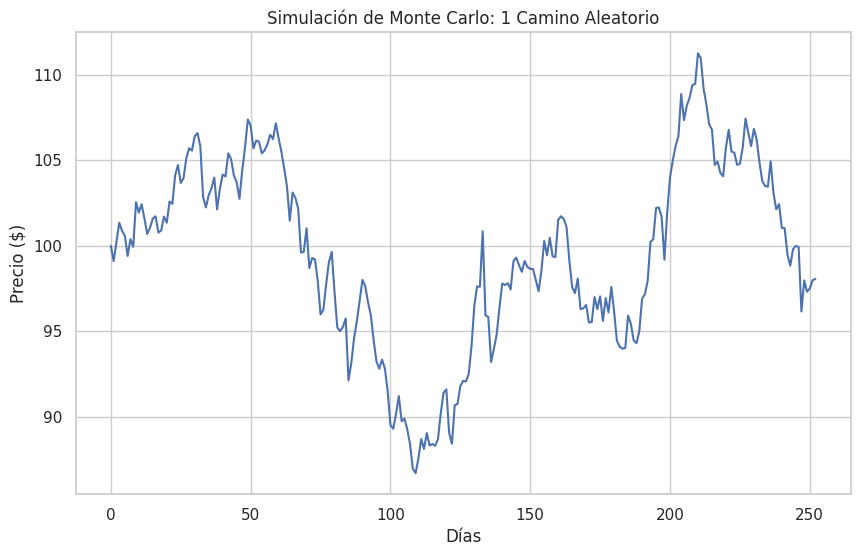

Precio Inicial: $100.00
Precio Final (Simulado): $98.07


In [12]:
import numpy as np
import matplotlib.pyplot as plt # Importamos librería para graficar

# 1. CONFIGURACIÓN DEL ESCENARIO
S0 = 100          # Precio inicial de la acción ($100)
T = 252           # Días de trading en un año
mu = 0.10         # Drift (Retorno esperado anual: 10%)
sigma = 0.20      # Volatilidad (Riesgo anual: 20%)

# 2. CONVERTIR PARAMETROS ANUALES A DIARIOS
# (Dividimos por 252 para drift y raíz de 252 para volatilidad, simplificado para este ejemplo)
mu_diario = mu / T
sigma_diario = sigma / np.sqrt(T)

# 3. GENERAR LOS CHOQUES ALEATORIOS (EL "RUIDO")
# Creamos T choques aleatorios con distribución Normal (promedio 0, escala 1)
# np.random.normal() es la clave aquí
choques = np.random.normal(0, 1, T)

# 4. CALCULAR LOS RETORNOS DIARIOS
# Retorno = Drift Diario + (Volatilidad Diaria * Choque Aleatorio)
retornos_diarios = mu_diario + (sigma_diario * choques)

# 5. CONSTRUIR EL CAMINO DE PRECIOS
# Empezamos con el precio inicial
precios = [S0]

# Bucle día a día: Precio Hoy = Precio Ayer * (1 + Retorno)
for retorno in retornos_diarios:
    precio_ayer = precios[-1]
    precio_hoy = precio_ayer * (1 + retorno)
    precios.append(precio_hoy)

# 6. VISUALIZAR EL RESULTADO
plt.figure(figsize=(10,6))
plt.plot(precios)
plt.title(f"Simulación de Monte Carlo: 1 Camino Aleatorio")
plt.xlabel("Días")
plt.ylabel("Precio ($)")
plt.grid(True)
plt.show()

print(f"Precio Inicial: ${precios[0]:.2f}")
print(f"Precio Final (Simulado): ${precios[-1]:.2f}")

---

### Desviacion Estandar = Riesgo

En el lenguaje común, "Riesgo" significa "posibilidad de perder dinero". Pero en matemáticas financieras, **Riesgo significa Incertidumbre**.

Imagina dos activos que valen $100 hoy y prometen un retorno promedio del 5%:

* **Activo A (Bajo Riesgo):** Mañana valdrá entre $99 y $101.
* **Activo B (Alto Riesgo):** Mañana valdrá entre $50 y $150.

Ambos tienen el mismo promedio, pero la **dispersión** del Activo B es gigante. La Desviación Estándar () es la regla que mide esa dispersión.

* Mayor  = La campana de Gauss es más ancha = "No tengo idea de qué va a pasar" = **Mayor Riesgo**.

### La Visualización: El "Cono" de Incertidumbre

Vamos a generar un gráfico que muestre cómo el rango de precios posibles se abre con el tiempo.
Graficaremos:

1. **Múltiples caminos aleatorios** (para ver el caos).
2. **Las barreras teóricas** calculadas con la fórmula . Verás que la mayoría de los caminos se quedan atrapados dentro de esas barreras curvas.

### ¿Por qué la Raíz Cuadrada del Tiempo ($\sqrt{t}$)?

Esta es la pregunta del millón. ¿Por qué no multiplicamos la volatilidad por el tiempo linealmente como hicimos con el Drift?

**La respuesta está en la Varianza.**

Cuando sumas eventos aleatorios independientes (como los retornos de cada día), lo que se suma linealmente es la **Varianza** (), no la Desviación Estándar.

* Día 1: Varianza 
* Día 2: Varianza 
* ...
* Día T: Varianza Total = $T \times \sigma^2$

Pero nosotros queremos hablar en términos de Desviación Estándar (porque está en la misma unidad que el precio, dólares, no "dólares cuadrados"). Para obtener la Desviación Estándar total, debemos sacar la raíz cuadrada de la Varianza Total:

$$\text{Riesgo Total} = \sqrt{\text{Varianza Total}} = \sqrt{T \times \sigma^2} = \sigma \times \sqrt{T}$$

**La Analogía Física (Difusión):**
Imagina una gota de tinta cayendo en un vaso de agua. Al principio está concentrada. Con el tiempo, se expande.
La tinta no se expande en línea recta; se difunde. La distancia que las partículas de tinta se alejan del centro crece proporcionalmente a la raíz cuadrada del tiempo. Los precios hacen lo mismo: se "difunden" desde el precio inicial.

#### La Visualización: El "Cono" de Incertidumbre

Vamos a generar un gráfico que muestre cómo el rango de precios posibles se abre con el tiempo.Graficaremos:
1. Múltiples caminos aleatorios (para ver el caos).
2. Las barreras teóricas calculadas con la fórmula $\pm \sigma \sqrt{t}$. Verás que la mayoría de los caminos se quedan atrapados dentro de esas barreras curvas.

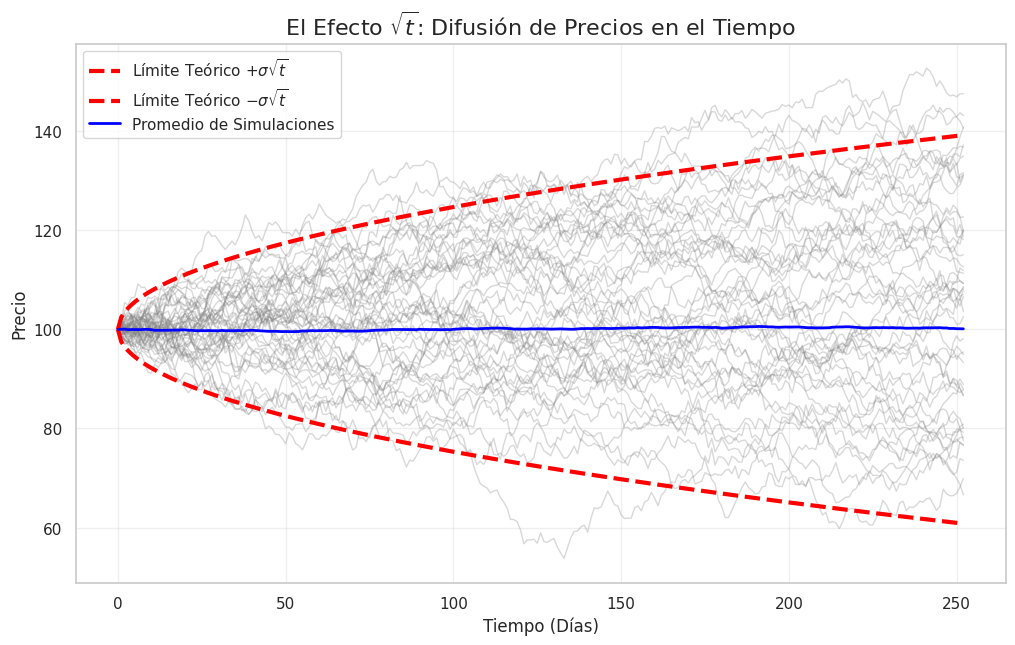

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 1. PARÁMETROS
N_simulaciones = 1000   # Número de caminos a simular
T = 252                 # Días (Tiempo)
sigma_anual = 0.20      # Volatilidad anual (20%)
S0 = 100                # Precio Inicial

# Escalar volatilidad a diaria
sigma_diaria = sigma_anual / np.sqrt(T)

# 2. GENERAR SIMULACIONES (MATRIZ GIGANTE)
# Generamos 1000 caminos de 252 pasos a la vez
# Shape: (252, 1000)
choques = np.random.normal(0, 1, (T, N_simulaciones))

# Caminata aleatoria acumulada (suma acumulativa de los choques)
# Esto crea el movimiento browniano: W_t
caminos_aleatorios = np.cumsum(choques, axis=0)

# Convertimos a precios (Simplificado: Solo volatilidad, sin drift para ver el efecto puro)
# Precio = Precio Inicial + (Volatilidad Diaria * Acumulado de Choques)
# Nota: Usamos una aproximación aritmética simple para visualizar la dispersión pura
precios_simulados = S0 + (S0 * sigma_diaria * caminos_aleatorios)

# Añadimos el punto inicial (Día 0, Precio 100) a todos los caminos
precios_simulados = np.vstack([np.full((1, N_simulaciones), S0), precios_simulados])

# 3. CALCULAR EL CONO TEÓRICO (La fórmula de la Raíz Cuadrada)
dias = np.arange(T + 1)
# El riesgo crece con la raíz del tiempo: sigma * sqrt(t)
# Multiplicamos por S0 para ponerlo en términos de dinero
limite_superior = S0 + (S0 * sigma_diaria * np.sqrt(dias) * 1.96) # 1.96 es el 95% de confianza
limite_inferior = S0 - (S0 * sigma_diaria * np.sqrt(dias) * 1.96)

# 4. VISUALIZACIÓN
plt.figure(figsize=(12, 7))

# A. Graficar los primeros 50 caminos simulados (en gris tenue)
plt.plot(precios_simulados[:, :50], color='gray', alpha=0.3, linewidth=1)

# B. Graficar el Cono de la Raíz Cuadrada (Líneas Rojas)
plt.plot(dias, limite_superior, color='red', linewidth=3, linestyle='--', label=r'Límite Teórico $+\sigma\sqrt{t}$')
plt.plot(dias, limite_inferior, color='red', linewidth=3, linestyle='--', label=r'Límite Teórico $-\sigma\sqrt{t}$')

# C. Graficar el promedio (debería ser plano porque quitamos el drift)
plt.plot(np.mean(precios_simulados, axis=1), color='blue', linewidth=2, label='Promedio de Simulaciones')

plt.title(r"El Efecto $\sqrt{t}$: Difusión de Precios en el Tiempo", fontsize=16)
plt.xlabel("Tiempo (Días)", fontsize=12)
plt.ylabel("Precio", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Análisis del Gráfico

Cuando ejecutes esto, verás algo parecido a un tornado horizontal o un embudo.

1. **Al inicio (Día 1):** El embudo es estrecho. La raíz cuadrada de 1 es 1. Hay poca incertidumbre.
2. **Al final (Día 252):** El embudo es muy ancho. La raíz cuadrada de 252 es aprox 15.8. El riesgo se ha acumulado.
3. **La forma:** Fíjate que las líneas rojas **no son rectas**. Son curvas parabólicas (acostadas). Crecen rápido al principio y luego se "suavizan" un poco, pero nunca dejan de crecer.


**Pregunta de verificación:**
Mirando el gráfico y pensando en la fórmula .
Si esperamos **4 años** en lugar de **1 año**, el tiempo se multiplica por 4.
¿El riesgo (la anchura del cono) se multiplica también por 4? ¿O por cuánto se multiplica?

El cono se hace ancho porque el tiempo le da oportunidad al azar de alejarse del origen. Más tiempo = Más oportunidades de desviarse = Rango posible más amplio. 
Esa "lentitud" matemática es la Raíz Cuadrada. La raíz cuadrada crece, pero cada vez crece más despacio (la curva se acuesta).

---
> El riesgo aumenta con el tiempo, pero crece más lento que el tiempo.
---

## Ejercicio

Tengo esta acción que vale 100 USD. Tiene volatilidad del 20%. ¿Cuál es la probabilidad de que termine valiendo menos de 90 USD al final del año?

In [15]:
import numpy as np

# 1. DATOS
S0 = 100          # Precio inicial
K = 90            # Precio "miedo" (Strike) - Queremos saber si cae bajo esto
T = 252           # Días
mu = 0.10         # Drift 10%
sigma = 0.20      # Volatilidad 20%
N_simulaciones = 10000 # Hacemos 10,000 escenarios

# 2. SIMULACIÓN VECTORIZADA (Rápida)
# Calculamos solo el PRECIO FINAL, no necesitamos el camino día a día
# Fórmula directa del precio final (Solución exacta del Movimiento Browniano)
# St = S0 * exp( (mu - 0.5*sigma^2)*T + sigma*sqrt(T)*Z )

# Generamos 10,000 valores aleatorios (Z) de una vez
Z = np.random.normal(0, 1, N_simulaciones)

# Aplicamos la fórmula para obtener 10,000 precios finales del año
# Nota: Usamos T/252 = 1 año. Si T fuera días, ajustamos los factores.
# Para simplificar, asumiremos que los parmetros mu y sigma ya son anuales y T=1 año.
precios_finales = S0 * np.exp((mu - 0.5 * sigma**2) * 1 + sigma * np.sqrt(1) * Z)

# 3. CONTEO (Monte Carlo)
# Creamos un array de True/False: ¿El precio final es menor a 90?
casos_malos = precios_finales < K

# Sumamos los True y dividimos por el total
probabilidad = np.sum(casos_malos) / N_simulaciones

print(f"Escenario: Acción a ${S0}, Volatilidad {sigma*100}%")
print(f"Simulando {N_simulaciones} años posibles...")
print(f"Probabilidad de caer bajo ${K}: {probabilidad:.2%}")

# Verificación rápida del promedio
print(f"Precio promedio esperado: ${np.mean(precios_finales):.2f}")

Escenario: Acción a $100, Volatilidad 20.0%
Simulando 10000 años posibles...
Probabilidad de caer bajo $90: 18.38%
Precio promedio esperado: $110.27
